In [2]:
from cProfile import label

import numpy as np
import matplotlib.pyplot as plt
import torch

In [3]:
x = torch.arange(-3, 3, 0.1).view(-1, 1)
f = -3 * x

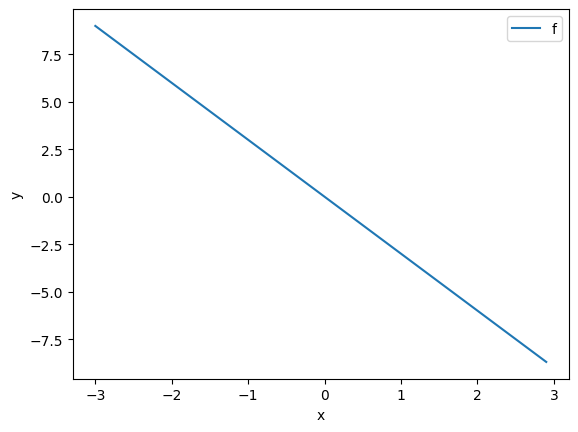

In [6]:
plt.plot(x.numpy(), f.numpy(), label= 'f')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [7]:
y = f + 0.1 * torch.randn(x.size())
y

tensor([[ 9.1504],
        [ 8.8268],
        [ 8.3468],
        [ 8.1264],
        [ 7.8766],
        [ 7.3742],
        [ 7.1107],
        [ 6.7762],
        [ 6.5365],
        [ 6.3666],
        [ 5.9926],
        [ 5.8050],
        [ 5.3771],
        [ 5.1197],
        [ 4.8055],
        [ 4.4165],
        [ 4.0651],
        [ 3.8489],
        [ 3.5000],
        [ 3.2597],
        [ 3.1387],
        [ 2.6627],
        [ 2.4481],
        [ 2.1837],
        [ 1.7597],
        [ 1.5031],
        [ 1.1436],
        [ 0.9622],
        [ 0.5713],
        [ 0.2536],
        [ 0.1083],
        [-0.1906],
        [-0.6293],
        [-0.9011],
        [-1.3261],
        [-1.5121],
        [-1.9334],
        [-1.9028],
        [-2.5021],
        [-2.7666],
        [-3.2065],
        [-3.4502],
        [-3.5970],
        [-3.8816],
        [-4.2334],
        [-4.4800],
        [-4.6963],
        [-4.9727],
        [-5.5601],
        [-5.7571],
        [-5.9773],
        [-6.4848],
        [-6.

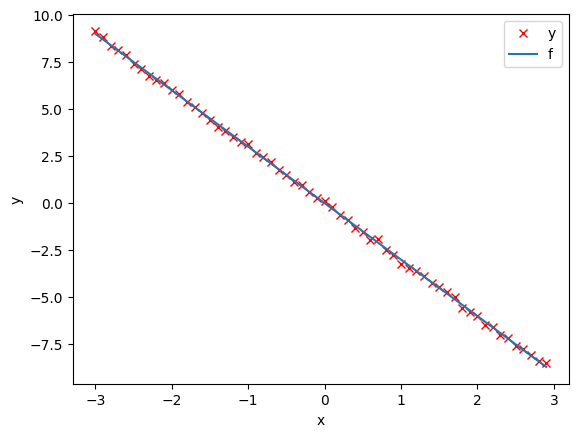

In [16]:
plt.plot(x.numpy(), y.numpy(), 'rx', label='y')
plt.plot(x.numpy(), f.numpy(), label = 'f')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [17]:
w = torch.tensor(-10.0, requires_grad = True)

def forward(x):
    return w * x

def criterion(yhat, y):
    return torch.mean((yhat - y) ** 2)

lr = 0.01
LOSS = []

class plot_diagram():

    # Constructor
    def __init__(self, X, Y, w, stop, go = False):
        start = w.data
        self.error = []
        self.parameter = []
        print(type(X.numpy()))
        self.X = X.numpy()

        self.Y = Y.numpy()
        self.parameter_values = torch.arange(start, stop)
        self.Loss_function = [criterion(forward(X), Y) for w.data in self.parameter_values]
        w.data = start

    # Executor
    def __call__(self, Yhat, w, error, n):
        self.error.append(error)
        self.parameter.append(w.data)
        plt.subplot(212)
        plt.plot(self.X, Yhat.detach().numpy())
        plt.plot(self.X, self.Y,'ro')
        plt.xlabel("A")
        plt.ylim(-20, 20)
        plt.subplot(211)
        plt.title("Data Space (top) Estimated Line (bottom) Iteration " + str(n))
        # Convert lists to PyTorch tensors
        parameter_values_tensor = torch.tensor(self.parameter_values)
        loss_function_tensor = torch.tensor(self.Loss_function)

        # Plot using the tensors
        plt.plot(parameter_values_tensor.numpy(), loss_function_tensor.numpy())

        plt.plot(self.parameter, self.error, 'ro')
        plt.xlabel("B")
        plt.figure()

    # Destructor
    def __del__(self):
        plt.close('all')

gradient_plot = plot_diagram(x, y, w, stop = 5)

<class 'numpy.ndarray'>


In [19]:
def train_model(iter):
    for epoch in range(iter):
        yhat = forward(x)
        loss = criterion(yhat, y)
        gradient_plot(yhat, w, loss.item(), epoch)
        LOSS.append(loss.item())
        loss.backward()
        w.data = w.data - lr * w.grad.data
        w.grad.data.zero_()

C:\Users\Murti\AppData\Local\Temp\ipykernel_2544\2975699803.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parameter_values_tensor = torch.tensor(self.parameter_values)
C:\Users\Murti\AppData\Local\Temp\ipykernel_2544\2975699803.py:47: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


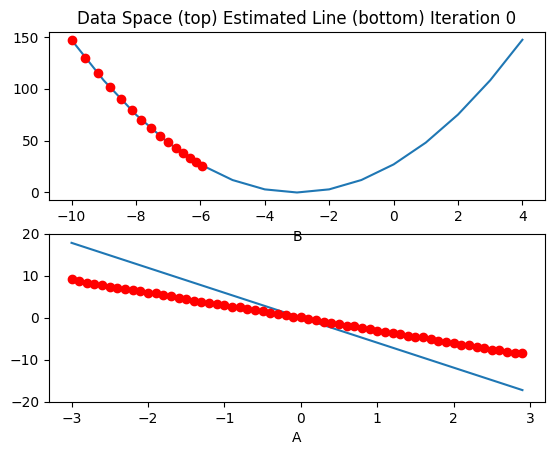

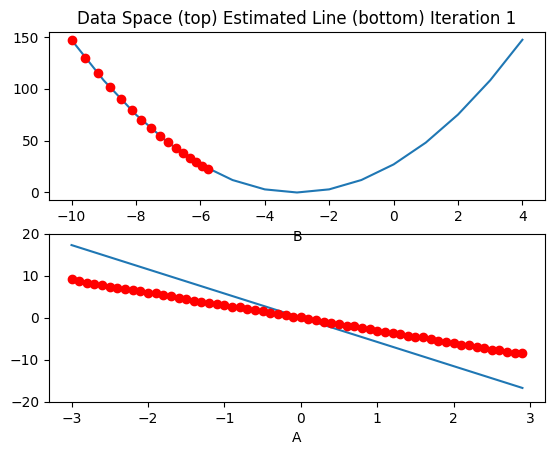

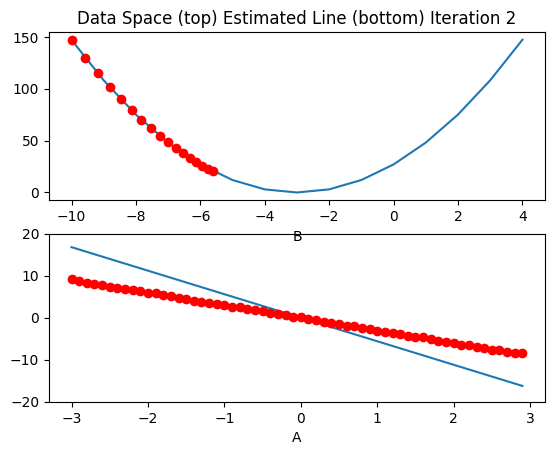

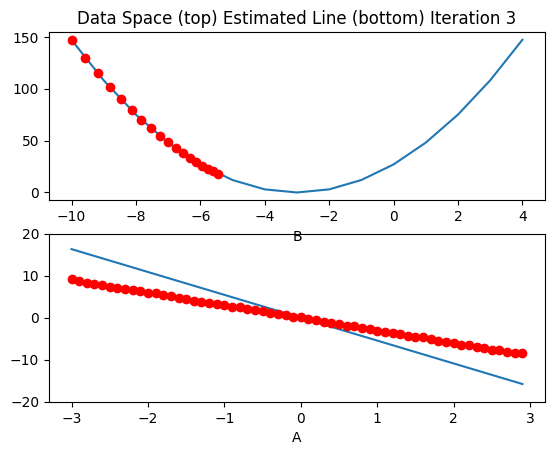

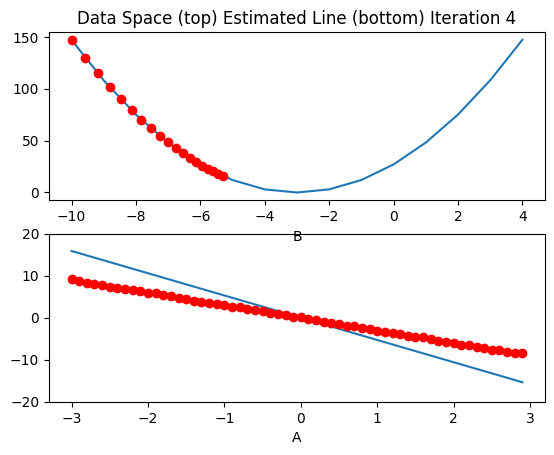

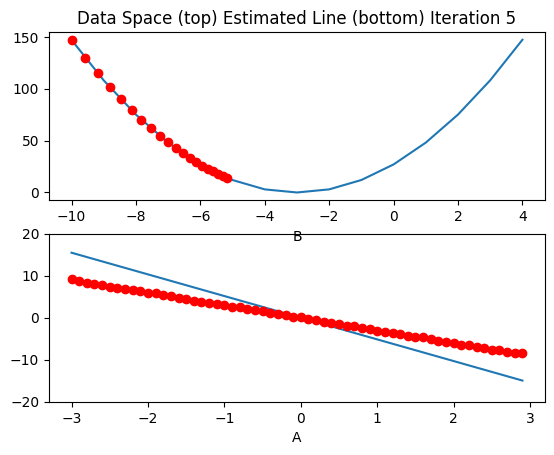

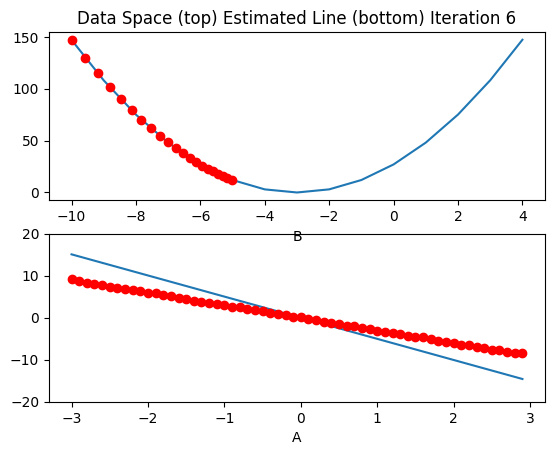

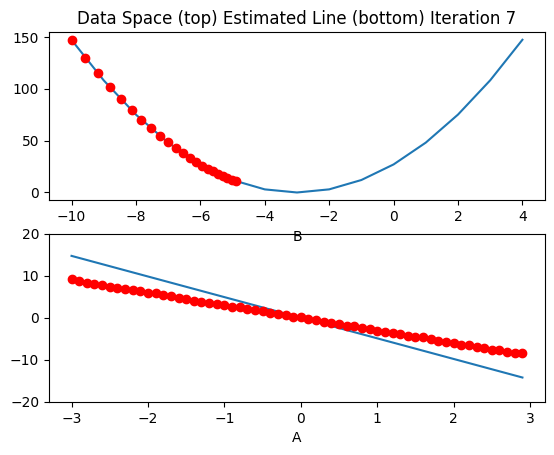

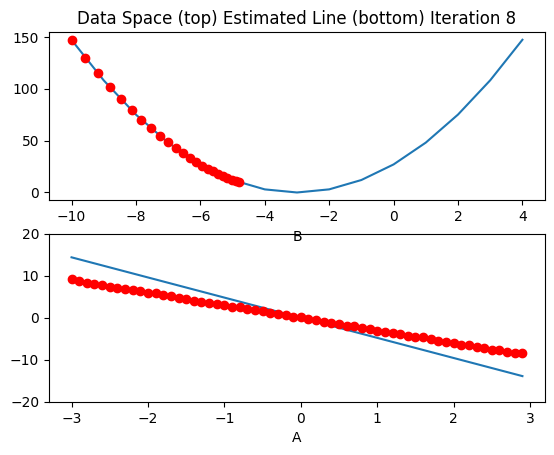

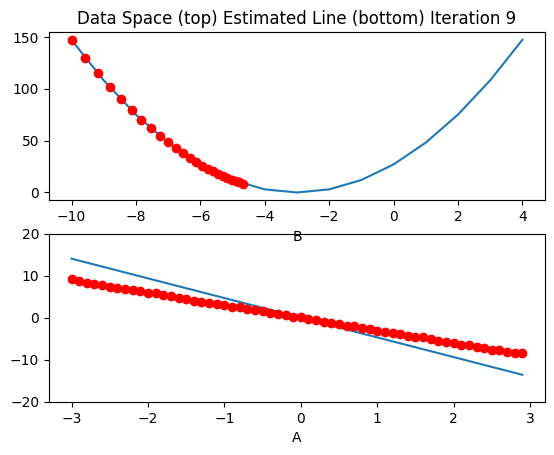

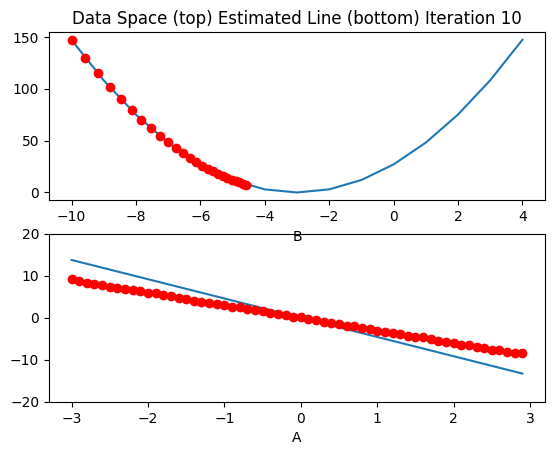

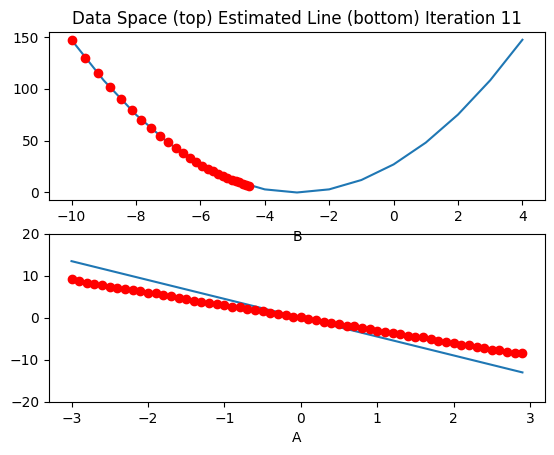

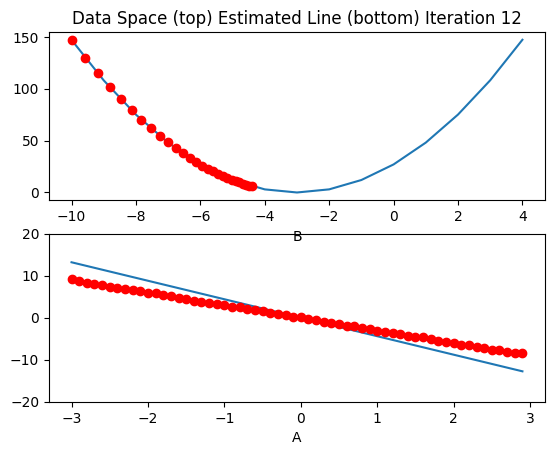

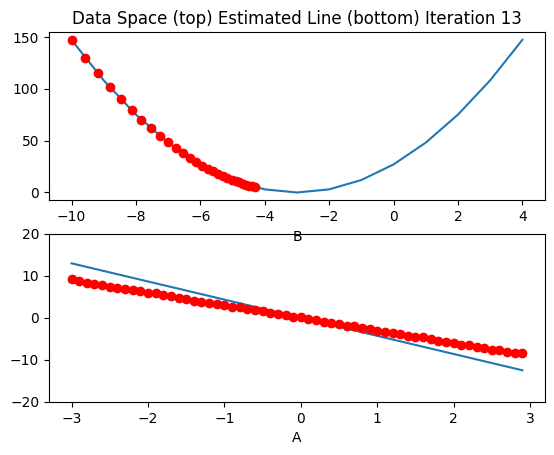

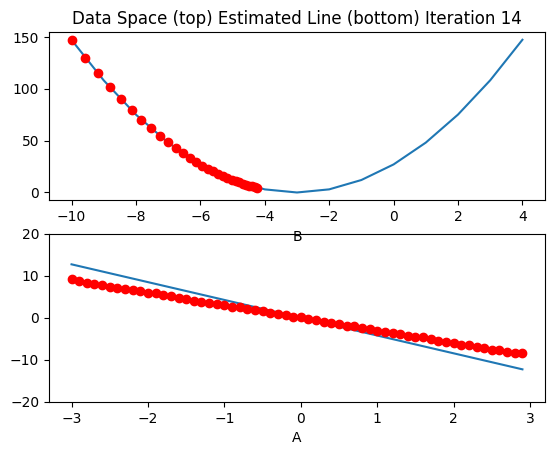

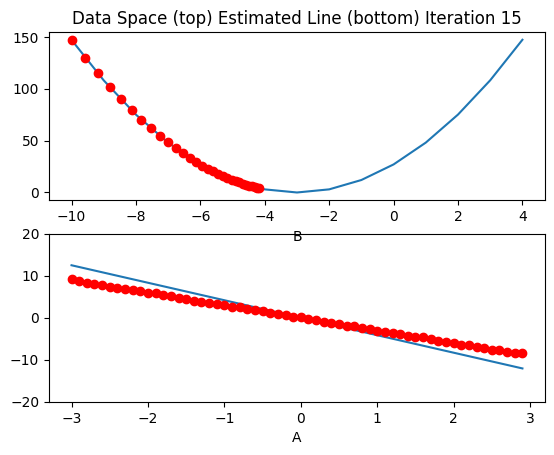

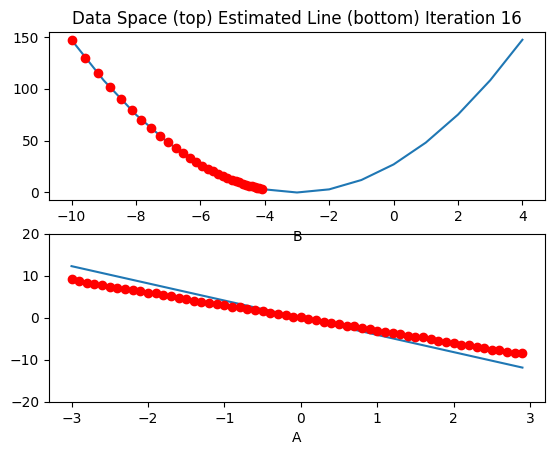

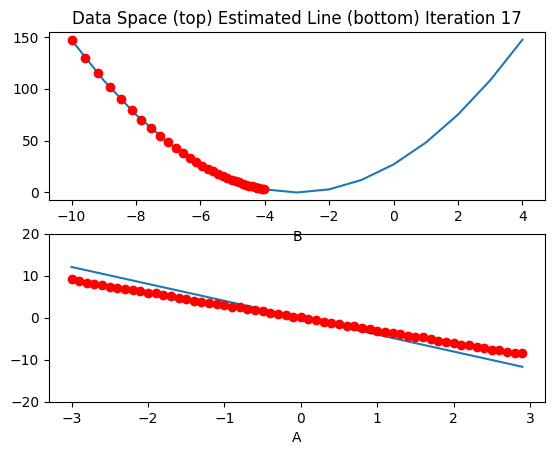

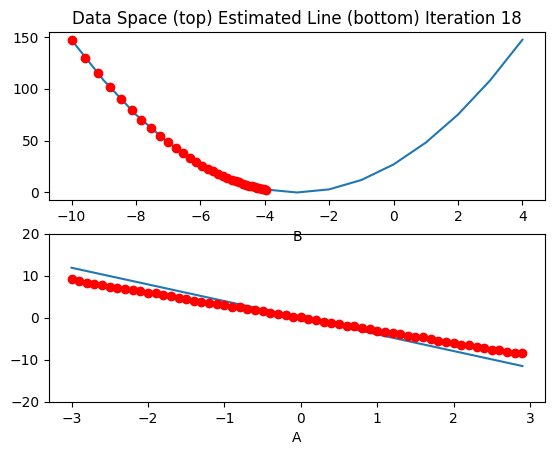

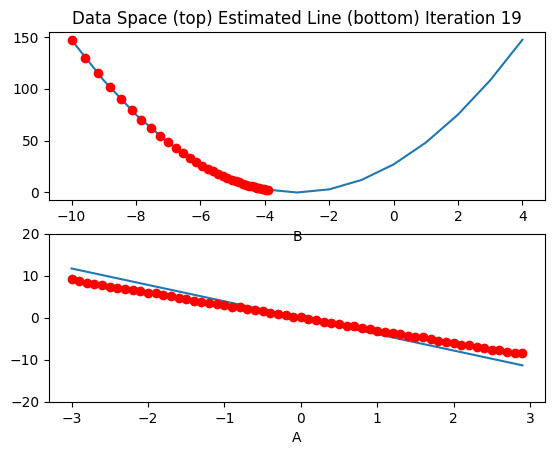

<Figure size 640x480 with 0 Axes>

In [23]:
train_model(20)

Text(38.347222222222214, 0.5, 'Cost')

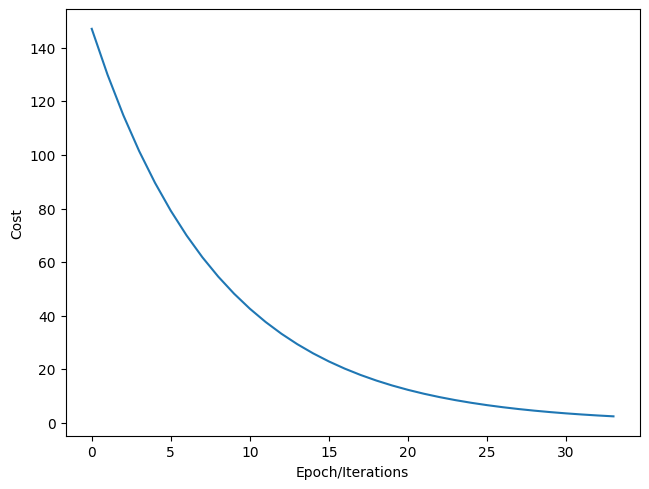

In [24]:
plt.plot(LOSS)
plt.tight_layout()
plt.xlabel("Epoch/Iterations")
plt.ylabel("Cost")